In [ ]:
from google.colab import files
uploaded = files.upload()

Saving star_classification.csv to star_classification.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score
)

In [ ]:
os.makedirs("plots", exist_ok=True)

In [ ]:
df = pd.read_csv("star_classification.csv")

In [ ]:
print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())

         obj_ID       alpha      delta         u         g         r  \
0  1.237661e+18  135.689107  32.494632  23.87882  22.27530  20.39501   
1  1.237665e+18  144.826101  31.274185  24.77759  22.83188  22.58444   
2  1.237661e+18  142.188790  35.582444  25.26307  22.66389  20.60976   
3  1.237663e+18  338.741038  -0.402828  22.13682  23.77656  21.61162   
4  1.237680e+18  345.282593  21.183866  19.43718  17.58028  16.49747   

          i         z  run_ID  rerun_ID  cam_col  field_ID   spec_obj_ID  \
0  19.16573  18.79371    3606       301        2        79  6.543777e+18   
1  21.16812  21.61427    4518       301        5       119  1.176014e+19   
2  19.34857  18.94827    3606       301        2       120  5.152200e+18   
3  20.50454  19.25010    4192       301        3       214  1.030107e+19   
4  15.97711  15.54461    8102       301        3       137  6.891865e+18   

    class  redshift  plate    MJD  fiber_ID  
0  GALAXY  0.634794   5812  56354       171  
1  GALAXY  0.77913

In [ ]:


print("Shape:", df.shape)
df.head()

Shape: (100000, 18)


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [ ]:
cols_to_drop = [
    'obj_ID', 'run_ID', 'rerun_ID',
    'cam_col', 'field_ID',
    'spec_obj_ID', 'fiber_ID',
    'plate', 'MJD'
]

df = df.drop(columns=cols_to_drop)

print(df.columns)

Index(['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'class', 'redshift'], dtype='object')


In [ ]:
X = df.drop('class', axis=1)
y = df['class']

print(X.shape)
print(y.shape)

(100000, 8)
(100000,)


In [ ]:
le = LabelEncoder()

y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)
print("Encoded labels:", np.unique(y_encoded))

Classes: ['GALAXY' 'QSO' 'STAR']
Encoded labels: [0 1 2]


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(100000, 8)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (80000, 8)
Testing: (20000, 8)


In [ ]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [ ]:
dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

print("\nClassification Report:")
print(classification_report(
    y_test,
    dt_pred,
    target_names=le.classes_
))

Decision Tree Accuracy: 0.96795

Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.96      0.99      0.97     11889
         QSO       0.96      0.87      0.91      3792
        STAR       1.00      1.00      1.00      4319

    accuracy                           0.97     20000
   macro avg       0.97      0.95      0.96     20000
weighted avg       0.97      0.97      0.97     20000



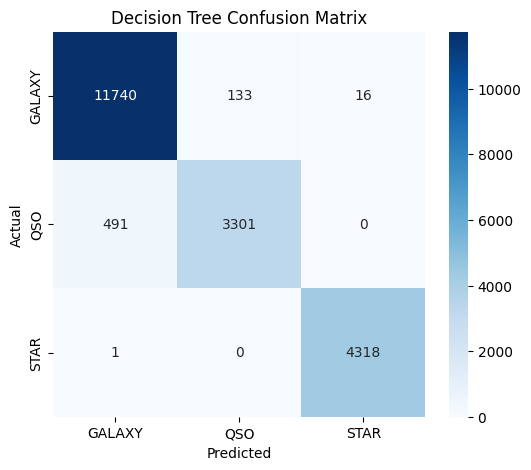

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, dt_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
k_values = range(1,16)

knn_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    pred = knn.predict(X_test)

    acc = accuracy_score(y_test, pred)

    knn_accuracies.append(acc)

best_k = k_values[np.argmax(knn_accuracies)]

print("Best K =", best_k)

Best K = 5


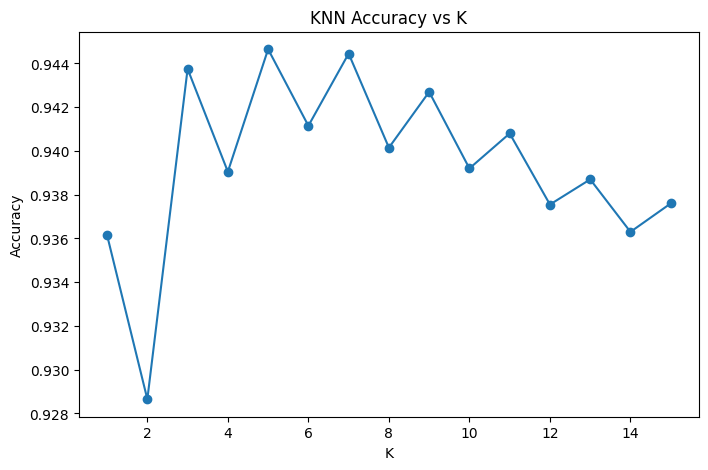

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    knn_accuracies,
    marker='o'
)

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")

plt.show()

In [ ]:
knn_model = KNeighborsClassifier(
    n_neighbors=best_k
)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

knn_acc = accuracy_score(
    y_test,
    knn_pred
)

print("KNN Accuracy:", knn_acc)

print("\nClassification Report:")
print(classification_report(
    y_test,
    knn_pred,
    target_names=le.classes_
))

KNN Accuracy: 0.94465

Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.95      0.96      0.95     11889
         QSO       0.97      0.90      0.93      3792
        STAR       0.92      0.94      0.93      4319

    accuracy                           0.94     20000
   macro avg       0.94      0.93      0.94     20000
weighted avg       0.95      0.94      0.94     20000



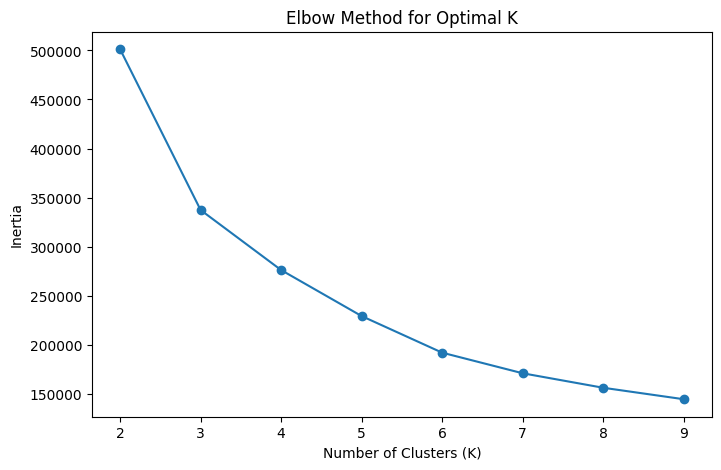

In [ ]:


from sklearn.cluster import KMeans

# Elbow Method
inertias = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertias.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    inertias,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')

plt.show()

In [ ]:
# Final K-Means Model
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

print("Cluster distribution:")
print(pd.Series(clusters).value_counts().sort_index())

Cluster distribution:
0    37646
1        1
2    62353
Name: count, dtype: int64


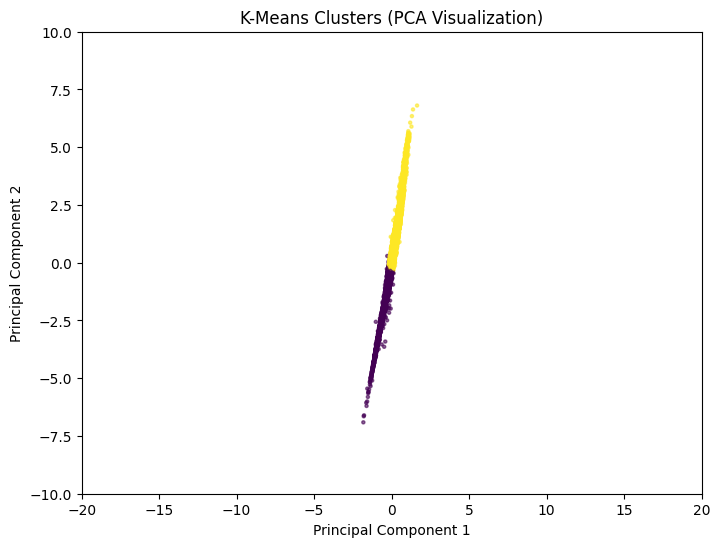

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap='viridis',
    s=5,
    alpha=0.6
)

plt.xlim(-20, 20)
plt.ylim(-10, 10)

plt.title('K-Means Clusters (PCA Visualization)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()

"K-Means clustering grouped the stellar observations into clusters based on feature similarity. The PCA visualization shows overlapping clusters, indicating that the dataset may not have clearly separable boundaries in two dimensions. Unlike Decision Trees and KNN, K-Means is an unsupervised learning algorithm and was evaluated through cluster formation rather than prediction accuracy."

In [ ]:
results = pd.DataFrame({
    'Model': ['Decision Tree', 'KNN', 'K-Means'],
    'Type': ['Supervised', 'Supervised', 'Unsupervised'],
    'Accuracy': [
        round(dt_acc, 4),
        round(knn_acc, 4),
        'N/A'
    ],
    'Metric': [
        f'Accuracy = {dt_acc:.4f}',
        f'Accuracy = {knn_acc:.4f}',
        'Elbow Method + Cluster Analysis'
    ]
})

print(results)

           Model          Type Accuracy                           Metric
0  Decision Tree    Supervised   0.9679                Accuracy = 0.9679
1            KNN    Supervised   0.9446                Accuracy = 0.9446
2        K-Means  Unsupervised      N/A  Elbow Method + Cluster Analysis
